## WEEK 8 Churn Prediction Model Development & Deployment 


### Environment Setup


In [6]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')
import os

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from imblearn.over_sampling import SMOTE

### Load & EDA


Shape: (7043, 21)

Dtypes:
 customerID              str
gender                  str
SeniorCitizen         int64
Partner                 str
Dependents              str
tenure                int64
PhoneService            str
MultipleLines           str
InternetService         str
OnlineSecurity          str
OnlineBackup            str
DeviceProtection        str
TechSupport             str
StreamingTV             str
StreamingMovies         str
Contract                str
PaperlessBilling        str
PaymentMethod           str
MonthlyCharges      float64
TotalCharges            str
Churn                   str
dtype: object

Missing Values:
 customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0


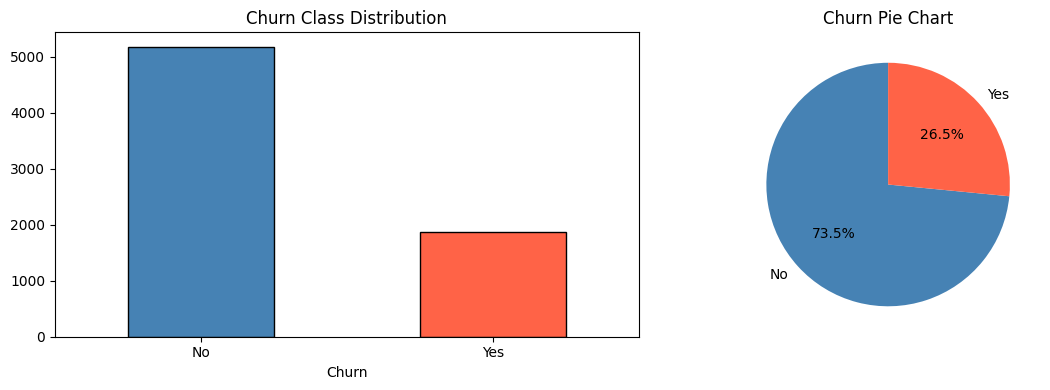

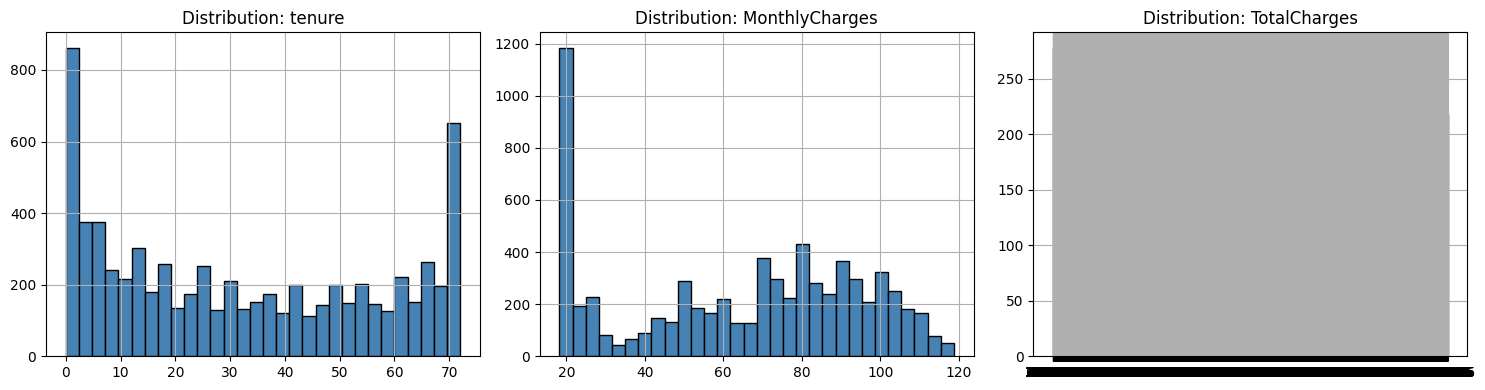

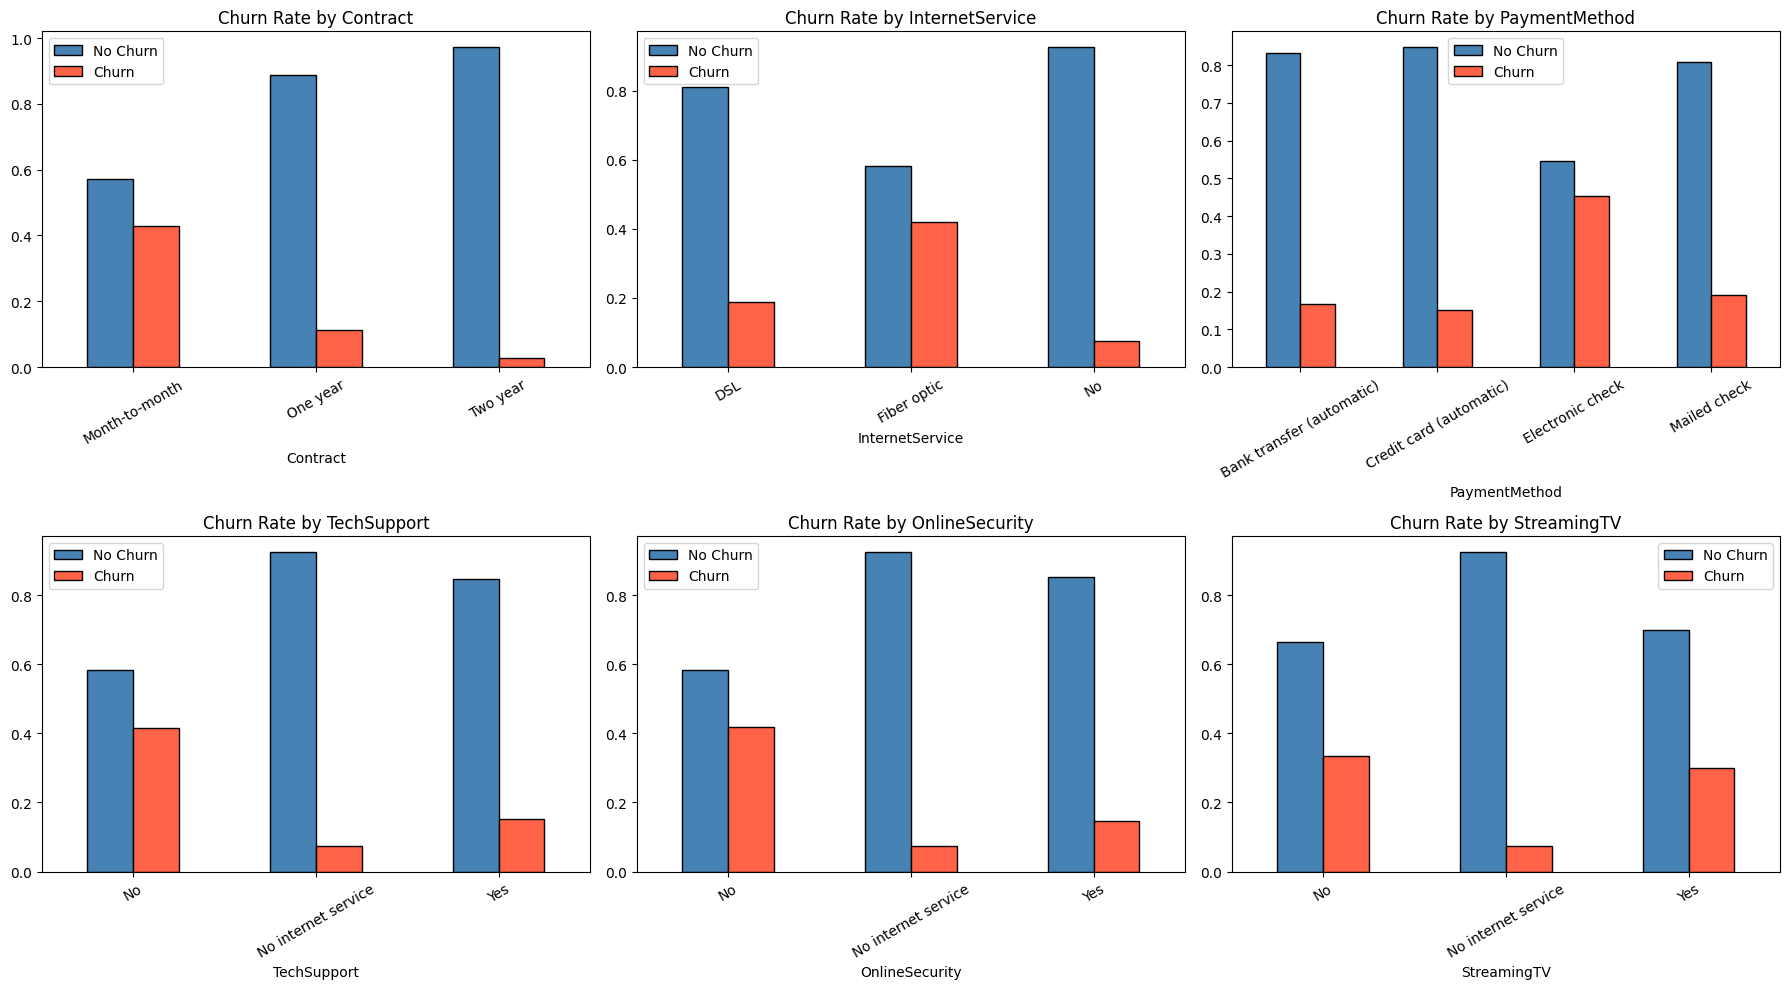

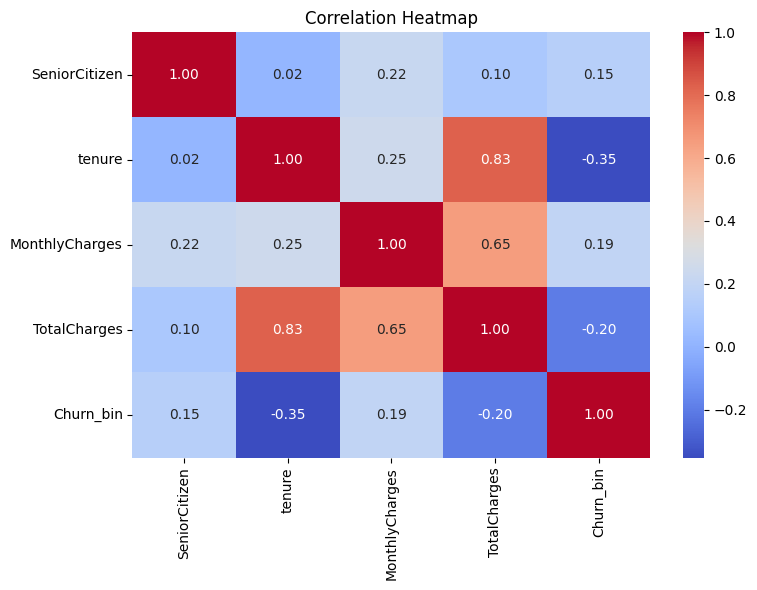

In [11]:
df = pd.read_csv(r'D:/All/CloudElligent/Telco_Churn_Prediction Using Sagemaker/WA_Fn-UseC_-Telco-Customer-Churn.csv')
print("Shape:", df.shape)
print("\nDtypes:\n", df.dtypes)
print("\nMissing Values:\n", df.isnull().sum())
print("\nDescribe:\n", df.describe())

# Class distribution
churn_counts = df['Churn'].value_counts()
print("\nChurn Distribution:\n", churn_counts)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
churn_counts.plot(kind='bar', ax=axes[0], color=['steelblue','tomato'], edgecolor='black')
axes[0].set_title('Churn Class Distribution')
axes[0].tick_params(axis='x', rotation=0)
axes[1].pie(churn_counts, labels=churn_counts.index, autopct='%1.1f%%',
            colors=['steelblue','tomato'], startangle=90)
axes[1].set_title('Churn Pie Chart')
plt.tight_layout(); plt.show()

# Numerical distributions
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, col in zip(axes, ['tenure', 'MonthlyCharges', 'TotalCharges']):
    df[col].hist(ax=ax, bins=30, color='steelblue', edgecolor='black')
    ax.set_title(f'Distribution: {col}')
plt.tight_layout(); plt.show()

# Churn rate by key categorical features
cat_features = ['Contract', 'InternetService', 'PaymentMethod',
                'TechSupport', 'OnlineSecurity', 'StreamingTV']
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
for ax, col in zip(axes.flatten(), cat_features):
    ct = df.groupby(col)['Churn'].value_counts(normalize=True).unstack().fillna(0)
    ct.plot(kind='bar', ax=ax, color=['steelblue','tomato'], edgecolor='black')
    ax.set_title(f'Churn Rate by {col}')
    ax.tick_params(axis='x', rotation=30)
    ax.legend(['No Churn','Churn'])
plt.tight_layout(); plt.show()

# Correlation heatmap
df_tmp = df.copy()
df_tmp['TotalCharges'] = pd.to_numeric(df_tmp['TotalCharges'], errors='coerce')
df_num = df_tmp.select_dtypes(include=[np.number]).copy()
df_num['Churn_bin'] = (df['Churn'] == 'Yes').astype(int)
plt.figure(figsize=(8, 6))
sns.heatmap(df_num.corr(), annot=True, fmt='.2f', cmap='coolwarm')
plt.title('Correlation Heatmap')
plt.tight_layout(); plt.show()

### Feature Engineering


In [12]:
# Always start from original df — never modify data in place across re-runs
data = df.copy()  # <-- use .copy() not drop()
data = data.drop(columns=['customerID'])

# Fix TotalCharges
data['TotalCharges'] = pd.to_numeric(data['TotalCharges'], errors='coerce')
median_tc = data['TotalCharges'].median()
data['TotalCharges'] = data['TotalCharges'].fillna(median_tc)

# Binary target
data['Churn'] = (data['Churn'] == 'Yes').astype(int)

# Average spend per month
data['AvgMonthlySpend'] = data['TotalCharges'] / (data['tenure'] + 1)

# Tenure bucket
data['TenureBucket'] = np.select(
    condlist=[
        data['tenure'] <= 12,
        data['tenure'] <= 24,
        data['tenure'] <= 48,
        data['tenure'] <= 72
    ],
    choicelist=[0, 1, 2, 3],
    default=3
)

# Number of active services
service_cols = ['PhoneService','MultipleLines','OnlineSecurity','OnlineBackup',
                'DeviceProtection','TechSupport','StreamingTV','StreamingMovies']
data['ServiceCount'] = data[service_cols].apply(lambda row: (row == 'Yes').sum(), axis=1)

# High monthly charge flag
data['HighValue'] = (data['MonthlyCharges'] > data['MonthlyCharges'].quantile(0.75)).astype(int)

# Highest risk combo
data['RiskCombo'] = (
    (data['Contract'] == 'Month-to-month') &
    (data['PaymentMethod'] == 'Electronic check')
).astype(int)

# No internet services at all
internet_services = ['OnlineSecurity','OnlineBackup','DeviceProtection',
                     'TechSupport','StreamingTV','StreamingMovies']
data['NoInternetServices'] = data[internet_services].apply(
    lambda r: (r == 'No internet service').all(), axis=1
).astype(int)

# Verify
print("Shape:", data.shape)
print("Total NaNs:", data.isnull().sum().sum())
print("Unique Contract values:", data['Contract'].unique())
print("All good!" if data.isnull().sum().sum() == 0 else "Fix NaNs!")

Shape: (7043, 26)
Total NaNs: 0
Unique Contract values: <StringArray>
['Month-to-month', 'One year', 'Two year']
Length: 3, dtype: str
All good!


### Preprocessing & Encoding


In [13]:
# Ordinal encode Contract — use replace() instead of map() for ArrowString compatibility
data['Contract'] = data['Contract'].replace({
    'Month-to-month': 0, 'One year': 1, 'Two year': 2
}).astype(int)

# Binary Yes/No columns
for col in ['Partner', 'Dependents', 'PhoneService', 'PaperlessBilling']:
    data[col] = (data[col] == 'Yes').astype(int)

# Gender
data['gender'] = (data['gender'] == 'Male').astype(int)

# One-hot encode remaining categoricals
cat_ohe = data.select_dtypes(include='object').columns.tolist()
cat_ohe += data.select_dtypes(include='string').columns.tolist()  # catch ArrowString too
cat_ohe = list(set(cat_ohe))  # remove duplicates
print("Columns being one-hot encoded:", cat_ohe)
data = pd.get_dummies(data, columns=cat_ohe, drop_first=True)

# Convert all bool columns to int
bool_cols = data.select_dtypes(include='bool').columns.tolist()
data[bool_cols] = data[bool_cols].astype(int)

# Convert ALL columns to int64 safely
for col in data.columns:
    data[col] = pd.to_numeric(data[col], errors='coerce').fillna(0).astype(int)

# Verify
print("\nDtypes:\n", data.dtypes.value_counts())
print("Total NaNs:", data.isnull().sum().sum())
print("Unique Contract values:", data['Contract'].unique())

# Separate features and target
X = data.drop(columns=['Churn']).copy()
y = data['Churn'].copy()

# Scale numerical features
num_features = ['tenure', 'MonthlyCharges', 'TotalCharges', 'AvgMonthlySpend', 'ServiceCount']
scaler = StandardScaler()
X[num_features] = scaler.fit_transform(X[num_features])

# Final check
print("\nFinal feature matrix shape:", X.shape)
print("Total NaNs in X:", X.isnull().sum().sum())
print("Target distribution:\n", y.value_counts())
print("All good!" if X.isnull().sum().sum() == 0 else "Still have NaNs!")



Columns being one-hot encoded: ['InternetService', 'MultipleLines', 'PaymentMethod', 'OnlineSecurity', 'StreamingMovies', 'OnlineBackup', 'StreamingTV', 'TechSupport', 'DeviceProtection']

Dtypes:
 int64    36
Name: count, dtype: int64
Total NaNs: 0
Unique Contract values: [0 1 2]

Final feature matrix shape: (7043, 35)
Total NaNs in X: 0
Target distribution:
 Churn
0    5174
1    1869
Name: count, dtype: int64
All good!


###  Split & SMOTE


In [14]:
# Stratified 70 / 15 / 15 split
X_train_val, X_test, y_train_val, y_test = train_test_split(
    X, y, test_size=0.15, random_state=42, stratify=y
)
X_train, X_val, y_train, y_val = train_test_split(
    X_train_val, y_train_val,
    test_size=0.176,
    random_state=42, stratify=y_train_val
)

print(f"Train : {X_train.shape} | Churn rate: {y_train.mean():.3f}")
print(f"Val   : {X_val.shape}   | Churn rate: {y_val.mean():.3f}")
print(f"Test  : {X_test.shape}  | Churn rate: {y_test.mean():.3f}")

# SMOTE on training set ONLY
smote = SMOTE(random_state=42)
X_train_res, y_train_res = smote.fit_resample(X_train, y_train)

print(f"\nAfter SMOTE:")
print(f"  Train shape    : {X_train_res.shape}")
print(f"  Class dist     : {pd.Series(y_train_res).value_counts().to_dict()}")
print(f"  Any NaNs       : {np.isnan(X_train_res).sum()}")


Train : (4932, 35) | Churn rate: 0.265
Val   : (1054, 35)   | Churn rate: 0.266
Test  : (1057, 35)  | Churn rate: 0.265

After SMOTE:
  Train shape    : (7246, 35)
  Class dist     : {0: 3623, 1: 3623}
  Any NaNs       : gender                                   0
SeniorCitizen                            0
Partner                                  0
Dependents                               0
tenure                                   0
PhoneService                             0
Contract                                 0
PaperlessBilling                         0
MonthlyCharges                           0
TotalCharges                             0
AvgMonthlySpend                          0
TenureBucket                             0
ServiceCount                             0
HighValue                                0
RiskCombo                                0
NoInternetServices                       0
InternetService_Fiber optic              0
InternetService_No                       0
Multi

### Saving Output


In [15]:
os.makedirs('processed', exist_ok=True)

# SageMaker XGBoost requires: label FIRST column, NO header, CSV format
train_df = pd.concat([
    pd.Series(y_train_res, name='Churn'),
    pd.DataFrame(X_train_res, columns=X.columns)
], axis=1)

val_df = pd.concat([
    y_val.reset_index(drop=True),
    X_val.reset_index(drop=True)
], axis=1)

test_df = pd.concat([
    y_test.reset_index(drop=True),
    X_test.reset_index(drop=True)
], axis=1)

# Save WITHOUT header — SageMaker XGBoost requirement
train_df.to_csv('processed/train.csv',      index=False, header=False)
val_df.to_csv('processed/validation.csv',   index=False, header=False)
test_df.to_csv('processed/test.csv',        index=False, header=False)

# Save test WITH header for local evaluation reference
test_df.to_csv('processed/test_with_header.csv', index=False, header=True)

# Save feature column names for reference in SageMaker
pd.Series(X.columns.tolist()).to_csv('processed/feature_columns.csv', index=False)

# Verify
print("Files saved in /processed:")
for f in os.listdir('processed'):
    path = f'processed/{f}'
    df_check = pd.read_csv(path)
    print(f"  {f:35s} — rows: {len(df_check)}, cols: {len(df_check.columns)}")

print(f"\nTrain  rows : {len(train_df)}")
print(f"Val    rows : {len(val_df)}")
print(f"Test   rows : {len(test_df)}")
print("\nDone! Now manually upload train.csv, validation.csv, test.csv to your S3 bucket.")

Files saved in /processed:
  feature_columns.csv                 — rows: 35, cols: 1
  test.csv                            — rows: 1056, cols: 36
  test_with_header.csv                — rows: 1057, cols: 36
  train.csv                           — rows: 7245, cols: 36
  validation.csv                      — rows: 1053, cols: 36

Train  rows : 7246
Val    rows : 1054
Test   rows : 1057

Done! Now manually upload train.csv, validation.csv, test.csv to your S3 bucket.
